## Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/SkinLesionProject_DenseNet'
os.makedirs(SAVE_DIR, exist_ok=True)
print("Drive mounted ✅")
print(f"Save dir: {SAVE_DIR}")


Mounted at /content/drive
Drive mounted ✅
Save dir: /content/drive/MyDrive/SkinLesionProject_DenseNet


## Cell 2 — Install & Imports

In [2]:
import sys
!{sys.executable} -m pip install grad-cam --quiet --upgrade

import os, random, warnings, json, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

CFG = {
    'img_size'       : 224,
    'batch_size'     : 32,

    'phase1_epochs'  : 15,
    'phase2_epochs'  : 45,
    'phase1_lr'      : 5e-4,
    'phase2_head_lr' : 1e-4,
    'phase2_bb_lr'   : 1e-5,
    'warmup_epochs'  : 4,
    'dropout'        : 0.4,
    'label_smoothing': 0.1,
    'mixup_alpha'    : 0.2,
    'patience'       : 12,
    'grad_clip'      : 1.0,
    'num_workers'    : 2,        # Colab T4 has 2 CPUs
    'prefetch_factor': 3,
    'use_amp'        : True,
    'cache_dir'      : '/content/skin_cache',
    'device'         : 'cuda' if torch.cuda.is_available() else 'cpu',
    'p1_save_path'   : f'{SAVE_DIR}/best_model_phase1.pth',
    'p2_save_path'   : f'{SAVE_DIR}/best_model_phase2.pth',
}

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

print(f"Device : {CFG['device']}")
if CFG['device'] == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Model  : DenseNet-201")
print(f"Batch  : {CFG['batch_size']}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 102.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Model  : DenseNet-201
Batch  : 32


## Cell 3 — Load Dataset

In [3]:
from datasets import load_dataset

print("Loading dataset …")
dataset = load_dataset("ahmed-ai/skin-lesions-classification-dataset")
print(dataset)


Loading dataset …


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/24 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/24 [00:00<?, ?it/s]

data/train-00000-of-00024.parquet:   0%|          | 0.00/491M [00:00<?, ?B/s]

...

data/test-00002-of-00003.parquet:   0%|          | 0.00/365M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29322 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3660 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3674 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 29322
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 3660
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 3674
    })
})


## Cell 4 — Explore Class Distribution

Classes (14):

TRAIN — 29,322 images
  Actinic keratoses                  :   693  ( 2.4%)
  Basal cell carcinoma               : 2,658  ( 9.1%)
  Benign keratosis-like lesions      : 2,099  ( 7.2%)
  Chickenpox                         :   900  ( 3.1%)
  Cowpox                             :   792  ( 2.7%)
  Dermatofibroma                     :   191  ( 0.7%)
  HFMD                               : 1,932  ( 6.6%)
  Healthy                            : 1,368  ( 4.7%)
  Measles                            :   660  ( 2.3%)
  Melanocytic nevi                   : 10,300  (35.1%)
  Melanoma                           : 3,617  (12.3%)
  Monkeypox                          : 3,408  (11.6%)
  Squamous cell carcinoma            :   502  ( 1.7%)
  Vascular lesions                   :   202  ( 0.7%)

VALIDATION — 3,660 images
  Actinic keratoses                  :    86  ( 2.3%)
  Basal cell carcinoma               :   332  ( 9.1%)
  Benign keratosis-like lesions      :   262  ( 7.2%)
  Chickenpox     

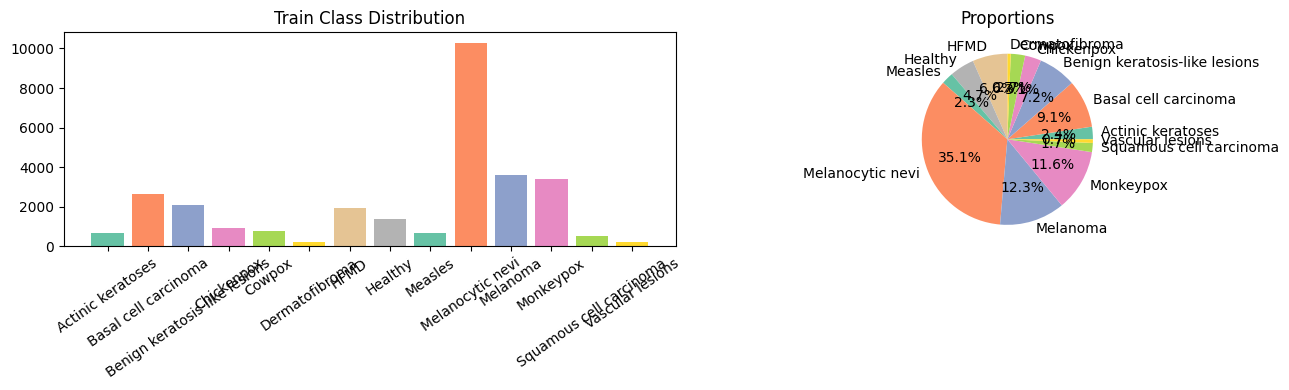

In [4]:
label_col   = 'label'
class_names = dataset['train'].features[label_col].names
num_classes = len(class_names)

print(f"Classes ({num_classes}):")
for split in ['train', 'validation', 'test']:
    ds     = dataset[split]
    counts = Counter(ds[label_col])
    total  = len(ds)
    print(f"\n{split.upper()} — {total:,} images")
    for i, name in enumerate(class_names):
        print(f"  {name:<35s}: {counts[i]:>5,}  ({counts[i]/total*100:4.1f}%)")

train_counts = Counter(dataset['train'][label_col])
values  = [train_counts[i] for i in range(num_classes)]
palette = sns.color_palette('Set2', num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(class_names, values, color=palette)
axes[0].set_title('Train Class Distribution')
axes[0].tick_params(axis='x', rotation=35)
axes[1].pie(values, labels=class_names, autopct='%1.1f%%', colors=palette)
axes[1].set_title('Proportions')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=120)
plt.show()


## Cell 5 — Sample Images

In [5]:
train_ds    = dataset['train']
labels_list = train_ds[label_col]
fig, axes   = plt.subplots(num_classes, 5, figsize=(15, 3 * num_classes))

for row, cls_idx in enumerate(range(num_classes)):
    cls_indices = [i for i, l in enumerate(labels_list) if l == cls_idx]
    for col, idx in enumerate(random.sample(cls_indices, min(5, len(cls_indices)))):
        img = train_ds[idx]['image'].convert('RGB')
        axes[row, col].imshow(img.resize((150, 150))); axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(class_names[cls_idx], fontsize=8, fontweight='bold')

plt.suptitle('Sample Images per Class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/sample_images.png', dpi=120)
plt.show()


Output hidden; open in https://colab.research.google.com to view.

## Cell 6 — Official HuggingFace Splits

In [6]:
train_hf = dataset['train']
val_hf   = dataset['validation']
test_hf  = dataset['test']

train_labels = np.array(train_hf[label_col])
val_labels   = np.array(val_hf[label_col])
test_labels  = np.array(test_hf[label_col])

print(f"Train : {len(train_hf):>6,}")
print(f"Val   : {len(val_hf):>6,}")
print(f"Test  : {len(test_hf):>6,}")


Train : 29,322
Val   :  3,660
Test  :  3,674


## Cell 7 — Pre-cache Images (run once per session)

In [7]:
from tqdm.auto import tqdm

CACHE_DIR = CFG['cache_dir']
IMG       = CFG['img_size']
os.makedirs(CACHE_DIR, exist_ok=True)

def cache_split(hf_ds, split_name, label_col, img_size, cache_dir):
    img_path = os.path.join(cache_dir, f'{split_name}_images.npy')
    lbl_path = os.path.join(cache_dir, f'{split_name}_labels.npy')
    if os.path.exists(img_path) and os.path.exists(lbl_path):
        print(f"  [{split_name}] Already cached — skipping.")
        return
    n      = len(hf_ds)
    images = np.empty((n, img_size, img_size, 3), dtype=np.uint8)
    labels = np.empty(n, dtype=np.int64)
    t0     = time.time()
    for i, sample in enumerate(tqdm(hf_ds, desc=split_name)):
        img = sample['image']
        if img.mode != 'RGB': img = img.convert('RGB')
        images[i] = np.array(img.resize((img_size, img_size), Image.BILINEAR))
        labels[i] = sample[label_col]
    np.save(img_path, images); np.save(lbl_path, labels)
    print(f"  [{split_name}] Done in {time.time()-t0:.0f}s  ({images.nbytes/1e6:.0f} MB)")

print("Pre-caching …")
for split, hf_ds in [('train', train_hf), ('validation', val_hf), ('test', test_hf)]:
    cache_split(hf_ds, split, label_col, IMG, CACHE_DIR)
print("\n✅ Cache ready.")


Pre-caching …


train:   0%|          | 0/29322 [00:00<?, ?it/s]

  [train] Done in 363s  (4414 MB)


validation:   0%|          | 0/3660 [00:00<?, ?it/s]

  [validation] Done in 39s  (551 MB)


test:   0%|          | 0/3674 [00:00<?, ?it/s]

  [test] Done in 44s  (553 MB)

✅ Cache ready.


## Cell 8 — Augmentations & Dataset

In [8]:
IMG = CFG['img_size']

train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.4),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15,
                       rotate_limit=25, border_mode=0, p=0.5),
    A.RandomBrightnessContrast(0.25, 0.25, p=0.5),
    A.HueSaturationValue(15, 25, 15, p=0.4),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.4),
    A.GaussNoise(var_limit=(10, 50), p=0.2),
    A.CoarseDropout(max_holes=8, max_height=IMG//12, max_width=IMG//12,
                    min_holes=1, min_height=IMG//24, min_width=IMG//24,
                    fill_value=0, p=0.3),
    A.Normalize(mean=MEAN.tolist(), std=STD.tolist()),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Normalize(mean=MEAN.tolist(), std=STD.tolist()),
    ToTensorV2(),
])

tta_transforms = [
    val_transforms,
    A.Compose([A.HorizontalFlip(p=1), A.Normalize(mean=MEAN.tolist(), std=STD.tolist()), ToTensorV2()]),
    A.Compose([A.VerticalFlip(p=1),   A.Normalize(mean=MEAN.tolist(), std=STD.tolist()), ToTensorV2()]),
    A.Compose([A.RandomRotate90(p=1), A.Normalize(mean=MEAN.tolist(), std=STD.tolist()), ToTensorV2()]),
]


class CachedSkinDataset(Dataset):
    def __init__(self, cache_dir, split, transforms=None):
        self.images     = np.load(os.path.join(cache_dir, f'{split}_images.npy'), mmap_mode='r')
        self.labels     = np.load(os.path.join(cache_dir, f'{split}_labels.npy'))
        self.transforms = transforms

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].copy()
        if self.transforms: img = self.transforms(image=img)['image']
        return img, torch.tensor(self.labels[idx], dtype=torch.long)


class TTADataset(Dataset):
    def __init__(self, cache_dir, split, tta_tfms):
        self.images   = np.load(os.path.join(cache_dir, f'{split}_images.npy'), mmap_mode='r')
        self.labels   = np.load(os.path.join(cache_dir, f'{split}_labels.npy'))
        self.tta_tfms = tta_tfms

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        img     = self.images[idx].copy()
        tensors = [t(image=img)['image'] for t in self.tta_tfms]
        return torch.stack(tensors), torch.tensor(self.labels[idx], dtype=torch.long)


class_counts   = np.bincount(train_labels)
sample_weights = (1.0 / class_counts)[train_labels]
sampler        = WeightedRandomSampler(
    weights=sample_weights.tolist(), num_samples=len(sample_weights), replacement=True
)

train_dataset = CachedSkinDataset(CACHE_DIR, 'train',      train_transforms)
val_dataset   = CachedSkinDataset(CACHE_DIR, 'validation', val_transforms)
test_dataset  = CachedSkinDataset(CACHE_DIR, 'test',       val_transforms)

_kw = dict(num_workers=CFG['num_workers'], pin_memory=True,
           persistent_workers=True, prefetch_factor=CFG['prefetch_factor'])

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'],
                          sampler=sampler, drop_last=True, **_kw)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'], shuffle=False, **_kw)
test_loader  = DataLoader(test_dataset,  batch_size=CFG['batch_size'], shuffle=False, **_kw)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

t0 = time.time()
for imgs, labels in train_loader: break
print(f"First batch   : {(time.time()-t0)*1000:.0f} ms  shape={list(imgs.shape)}")


Train batches : 916
Val   batches : 115
Test  batches : 115
First batch   : 1346 ms  shape=[32, 3, 224, 224]


## Cell 9 — DenseNet-201 Model



In [9]:
class SkinLesionModel(nn.Module):
    """
    DenseNet-201 backbone with custom classification head.

    """
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'densenet201', pretrained=True, num_classes=0
        )
        in_feat = self.backbone.num_features   # 1920 for DenseNet-201

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.BatchNorm1d(in_feat),
            nn.Dropout(p=dropout),
            nn.Linear(in_feat, 512),
            nn.ReLU(inplace=True),        # ReLU matches DenseNet's internal activation
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout * 0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.head(self.backbone.forward_features(x))

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        print("Backbone FROZEN")

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True
        print("Backbone UNFROZEN")

    def param_count(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Trainable : {trainable:>12,} / {total:,}  ({trainable/total*100:.1f}%)")


model = SkinLesionModel(num_classes=num_classes, dropout=CFG['dropout']).to(CFG['device'])
print("Model : DenseNet-201")
print(f"Input : {CFG['img_size']}×{CFG['img_size']}")
model.param_count()


model.safetensors:   0%|          | 0.00/81.1M [00:00<?, ?B/s]

Model : DenseNet-201
Input : 224×224
  Trainable :   19,088,526 / 19,088,526  (100.0%)


## Cell 10 — Focal Loss + Label Smoothing (no alpha)

In [10]:
class FocalLossWithSmoothing(nn.Module):
    """
    Focal Loss + Label Smoothing — NO alpha weight.
    WeightedRandomSampler handles class imbalance at the data level.
    Alpha on top = double correction → model predicts rare classes everywhere.
    """
    def __init__(self, gamma=2.0, smoothing=0.1, num_classes=1):
        super().__init__()
        self.gamma     = gamma
        self.smoothing = smoothing
        self.C         = num_classes

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        log_pt    = log_probs.gather(1, targets.view(-1, 1)).squeeze(1)
        pt        = log_pt.exp()
        focal_mod = (1 - pt) ** self.gamma
        if self.smoothing > 0:
            with torch.no_grad():
                q = torch.full_like(logits, self.smoothing / (self.C - 1))
                q.scatter_(1, targets.view(-1, 1), 1.0 - self.smoothing)
            loss = -(focal_mod.unsqueeze(1) * q * log_probs).sum(dim=1)
        else:
            loss = -(focal_mod * log_pt)
        return loss.mean()


criterion = FocalLossWithSmoothing(gamma=2.0, smoothing=0.1, num_classes=num_classes)
print(f"Loss  : FocalLoss(γ=2.0) + LabelSmoothing(ε=0.1)  — no alpha")


Loss  : FocalLoss(γ=2.0) + LabelSmoothing(ε=0.1)  — no alpha


## Cell 11 — Training Helpers

In [11]:
scaler = GradScaler(enabled=CFG['use_amp'])


def safe_normalize(probs: np.ndarray) -> np.ndarray:
    """Cast to float64 and renormalize — eliminates float32 precision drift
    that causes roc_auc_score ValueError: scores must sum to 1.0"""
    p = probs.astype(np.float64)
    p /= p.sum(axis=1, keepdims=True)
    return p


def mixup_batch(x, y, alpha):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def cutmix_batch(x, y, alpha=1.0):
    """
    CutMix: paste a rectangular patch from one image into another.
    Preserves local texture features — more effective than Mixup for
    rare classes (Dermatofibroma, Vascular lesions) where spatial
    texture is the key discriminative feature.
    """
    lam    = np.random.beta(alpha, alpha)
    B, _, H, W = x.shape
    idx    = torch.randperm(B, device=x.device)

    cut_h  = int(H * np.sqrt(1 - lam))
    cut_w  = int(W * np.sqrt(1 - lam))
    cy     = np.random.randint(H)
    cx     = np.random.randint(W)

    y1, y2 = max(cy - cut_h // 2, 0), min(cy + cut_h // 2, H)
    x1, x2 = max(cx - cut_w // 2, 0), min(cx + cut_w // 2, W)

    x_mix              = x.clone()
    x_mix[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam_actual         = 1 - (y2 - y1) * (x2 - x1) / (H * W)
    return x_mix, y, y[idx], lam_actual


def train_one_epoch(model, loader, optimizer, criterion, device, scaler,
                    scheduler=None, use_mixup=False, mixup_alpha=0.2):
    model.train()
    total_loss = correct = total = skipped = 0

    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        if use_mixup and mixup_alpha > 0:
            # Alternate between Mixup and CutMix — each handles different
            # aspects of generalization
            if random.random() < 0.5:
                imgs, y_a, y_b, lam = mixup_batch(imgs, labels, mixup_alpha)
            else:
                imgs, y_a, y_b, lam = cutmix_batch(imgs, labels, alpha=1.0)

            with autocast(enabled=CFG['use_amp']):
                logits = model(imgs)
                loss   = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
            preds   = logits.argmax(1)
            correct += (lam * (preds == y_a).float() +
                        (1 - lam) * (preds == y_b).float()).sum().item()
        else:
            with autocast(enabled=CFG['use_amp']):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            correct += (logits.argmax(1) == labels).sum().item()

        before = scaler.get_scale()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        scaler.step(optimizer); scaler.update()
        if scaler.get_scale() < before: skipped += 1

        if scheduler is not None: scheduler.step()   # OneCycleLR: per batch
        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)

    if skipped > 0:
        print(f"  ⚠️  Scaler skipped {skipped} steps (NaN/Inf grads)")
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast(enabled=CFG['use_amp']):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        probs  = F.softmax(logits, dim=1)
        preds  = probs.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    f1_w = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1_m = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
    return (total_loss / total, correct / total, f1_w, f1_m,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


@torch.no_grad()
def evaluate_tta(model, cache_dir, split, criterion, device, tta_tfms):
    tta_ds     = TTADataset(cache_dir, split, tta_tfms)
    tta_loader = DataLoader(tta_ds, batch_size=CFG['batch_size'], shuffle=False,
                            num_workers=CFG['num_workers'], pin_memory=True,
                            persistent_workers=True, prefetch_factor=CFG['prefetch_factor'])
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels, all_probs = [], [], []

    for batch_t, labels in tta_loader:
        labels = labels.to(device, non_blocking=True)
        B, K, C, H, W = batch_t.shape
        avg_p  = torch.zeros(B, num_classes, device=device)
        for k in range(K):
            imgs  = batch_t[:, k].to(device, non_blocking=True)
            with autocast(enabled=CFG['use_amp']):
                avg_p += F.softmax(model(imgs), dim=1)
        avg_p /= K
        preds  = avg_p.argmax(1)
        with autocast(enabled=CFG['use_amp']):
            loss = criterion(model(batch_t[:, 0].to(device)), labels)
        total_loss += loss.item() * B
        correct    += (preds == labels).sum().item()
        total      += B
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(avg_p.cpu().numpy())

    f1_w = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1_m = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
    return (total_loss / total, correct / total, f1_w, f1_m,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

print("Helpers ready ✅  (safe_normalize, mixup, cutmix, train, evaluate, evaluate_tta)")


Helpers ready ✅  (safe_normalize, mixup, cutmix, train, evaluate, evaluate_tta)


## Cell 12 — Phase 1: Head Warm-up (Backbone Frozen)

In [12]:
model.freeze_backbone()
model.param_count()

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG['phase1_lr'], weight_decay=1e-4,
)
scheduler_p1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_p1, max_lr=CFG['phase1_lr'],
    steps_per_epoch=len(train_loader),
    epochs=CFG['phase1_epochs'],
    pct_start=0.3, anneal_strategy='cos',
)

history = {k: [] for k in [
    'train_loss','train_acc','val_loss','val_acc','val_f1_w','val_f1_m','lr'
]}

print("=" * 72)
print("  PHASE 1 — Head warm-up (backbone frozen, no mixup)")
print(f"  Checkpoint: {CFG['p1_save_path']}  ← safe to re-run")
print("=" * 72)
print(f"{'Ep':>4} | {'TrLoss':>7} | {'TrAcc':>6} | {'VaLoss':>7} | {'VaAcc':>6} | {'F1-W':>6} | {'F1-M':>6} | {'s':>5}")
print("-" * 72)

best_p1_f1 = 0.0

for epoch in range(1, CFG['phase1_epochs'] + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer_p1, criterion, CFG['device'], scaler,
        scheduler=scheduler_p1, use_mixup=False,
    )
    val_loss, val_acc, val_f1_w, val_f1_m, _, _, _ = evaluate(
        model, val_loader, criterion, CFG['device'])
    elapsed = time.time() - t0

    for k, v in [('train_loss', tr_loss), ('train_acc', tr_acc),
                 ('val_loss', val_loss),   ('val_acc', val_acc),
                 ('val_f1_w', val_f1_w),  ('val_f1_m', val_f1_m),
                 ('lr', optimizer_p1.param_groups[0]['lr'])]:
        history[k].append(v)

    marker = " ✅" if val_f1_w > best_p1_f1 else ""
    print(f"{epoch:>4} | {tr_loss:>7.4f} | {tr_acc:>6.4f} | "
          f"{val_loss:>7.4f} | {val_acc:>6.4f} | "
          f"{val_f1_w:>6.4f} | {val_f1_m:>6.4f} | {elapsed:>4.0f}s{marker}")

    if val_f1_w > best_p1_f1:
        best_p1_f1 = val_f1_w
        torch.save({'epoch': epoch, 'phase': 'phase1',
                    'model_state': model.state_dict(),
                    'best_f1': best_p1_f1, 'class_names': class_names},
                   CFG['p1_save_path'])

print(f"\n  Best Val F1-W (Phase 1): {best_p1_f1:.4f}")
if best_p1_f1 < 0.35:
    print("  ⚠️  WARNING: F1 < 0.35 — head has not converged. Lower phase1_lr and re-run.")
else:
    print("  Phase 1 OK — proceed to Phase 2.")


Backbone FROZEN
  Trainable :      995,598 / 19,088,526  (5.2%)
  PHASE 1 — Head warm-up (backbone frozen, no mixup)
  Checkpoint: /content/drive/MyDrive/SkinLesionProject_DenseNet/best_model_phase1.pth  ← safe to re-run
  Ep |  TrLoss |  TrAcc |  VaLoss |  VaAcc |   F1-W |   F1-M |     s
------------------------------------------------------------------------
   1 |  1.6123 | 0.3301 |  0.9485 | 0.5511 | 0.5828 | 0.4799 |  154s ✅
   2 |  1.1292 | 0.4903 |  0.7551 | 0.6243 | 0.6502 | 0.5482 |  142s ✅
   3 |  1.0573 | 0.5147 |  0.7654 | 0.6112 | 0.6382 | 0.5618 |  145s
   4 |  0.9817 | 0.5475 |  0.6749 | 0.6486 | 0.6673 | 0.5787 |  147s ✅
  ⚠️  Scaler skipped 1 steps (NaN/Inf grads)
   5 |  0.9717 | 0.5511 |  0.6530 | 0.6516 | 0.6704 | 0.6102 |  148s ✅
   6 |  0.9258 | 0.5664 |  0.6397 | 0.6536 | 0.6790 | 0.6066 |  145s ✅
  ⚠️  Scaler skipped 1 steps (NaN/Inf grads)
   7 |  0.8963 | 0.5805 |  0.6132 | 0.6751 | 0.6935 | 0.6134 |  146s ✅
   8 |  0.8814 | 0.5847 |  0.6156 | 0.6617 | 0.6865 

## Cell 13 — Phase 2: Full Fine-tuning (Backbone Unfrozen)



In [13]:
ckpt = torch.load(CFG['p1_save_path'], map_location=CFG['device'], weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f"Phase-1 best loaded: epoch={ckpt['epoch']}  F1={ckpt['best_f1']:.4f}")

model.unfreeze_backbone()
model.param_count()

BB_LR     = CFG['phase2_bb_lr']
HEAD_LR   = CFG['phase2_head_lr']
WD_FACTOR = 0.1

optimizer_p2 = torch.optim.AdamW([
    {'params': model.backbone.parameters(),
     'lr': BB_LR,   'weight_decay': 1e-4},
    {'params': model.head.parameters(),
     'lr': HEAD_LR, 'weight_decay': 1e-4},
])

warmup_sched = torch.optim.lr_scheduler.LinearLR(
    optimizer_p2,
    start_factor=WD_FACTOR,
    end_factor=1.0,
    total_iters=CFG['warmup_epochs'],
)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_p2, T_0=8, T_mult=2, eta_min=1e-8,
)
scheduler_p2 = torch.optim.lr_scheduler.SequentialLR(
    optimizer_p2,
    schedulers=[warmup_sched, cosine_sched],
    milestones=[CFG['warmup_epochs']],
)

print("\n" + "=" * 72)
print("  PHASE 2 — Full fine-tuning  (Mixup+CutMix ON, Differential LRs)")
print(f"  BB LR: {BB_LR*WD_FACTOR:.1e}→{BB_LR:.1e}  |  Head LR: {HEAD_LR*WD_FACTOR:.1e}→{HEAD_LR:.1e}")
print(f"  Warmup: {CFG['warmup_epochs']}ep  |  Max: {CFG['phase2_epochs']}ep  |  Patience: {CFG['patience']}")

print(f"  Saving to: {CFG['p2_save_path']}")
print("=" * 72)
print(f"{'Ep':>4} | {'TrLoss':>7} | {'TrAcc':>6} | {'VaLoss':>7} | {'VaAcc':>6} | {'F1-W':>6} | {'F1-M':>6} | {'s':>5}")
print("-" * 72)

best_p2_f1   = 0.0
patience_ctr = 0

for epoch in range(1, CFG['phase2_epochs'] + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer_p2, criterion, CFG['device'], scaler,
        scheduler=None, use_mixup=True, mixup_alpha=CFG['mixup_alpha'],
    )
    val_loss, val_acc, val_f1_w, val_f1_m, _, _, _ = evaluate(
        model, val_loader, criterion, CFG['device'])
    scheduler_p2.step()
    elapsed = time.time() - t0

    for k, v in [('train_loss', tr_loss), ('train_acc', tr_acc),
                 ('val_loss', val_loss),   ('val_acc', val_acc),
                 ('val_f1_w', val_f1_w),  ('val_f1_m', val_f1_m),
                 ('lr', optimizer_p2.param_groups[1]['lr'])]:
        history[k].append(v)

    marker = " ✅" if val_f1_w > best_p2_f1 else ""
    print(f"{epoch:>4} | {tr_loss:>7.4f} | {tr_acc:>6.4f} | "
          f"{val_loss:>7.4f} | {val_acc:>6.4f} | "
          f"{val_f1_w:>6.4f} | {val_f1_m:>6.4f} | {elapsed:>4.0f}s{marker}")

    if val_f1_w > best_p2_f1:
        best_p2_f1   = val_f1_w
        patience_ctr = 0
        torch.save({'epoch': epoch, 'phase': 'phase2',
                    'model_state': model.state_dict(),
                    'best_f1': best_p2_f1, 'class_names': class_names},
                   CFG['p2_save_path'])
    else:
        patience_ctr += 1
        if patience_ctr >= CFG['patience']:
            print(f"\n  Early stopping — {CFG['patience']} epochs no improvement")
            break

print(f"\n  Best Val F1-W (Phase 2): {best_p2_f1:.4f}")
print(f"  Checkpoint: {CFG['p2_save_path']}")

Phase-1 best loaded: epoch=14  F1=0.7404
Backbone UNFROZEN
  Trainable :   19,088,526 / 19,088,526  (100.0%)

  PHASE 2 — Full fine-tuning  (Mixup+CutMix ON, Differential LRs)
  BB LR: 1.0e-06→1.0e-05  |  Head LR: 1.0e-05→1.0e-04
  Warmup: 4ep  |  Max: 45ep  |  Patience: 12
  Saving to: /content/drive/MyDrive/SkinLesionProject_DenseNet/best_model_phase2.pth
  Ep |  TrLoss |  TrAcc |  VaLoss |  VaAcc |   F1-W |   F1-M |     s
------------------------------------------------------------------------
  ⚠️  Scaler skipped 5 steps (NaN/Inf grads)
   1 |  1.4356 | 0.4695 |  0.5646 | 0.6997 | 0.7180 | 0.6431 |  302s ✅
   2 |  1.3388 | 0.4935 |  0.5192 | 0.7172 | 0.7339 | 0.6719 |  287s ✅
   3 |  1.3057 | 0.5026 |  0.5085 | 0.7363 | 0.7481 | 0.6891 |  287s ✅
   4 |  1.2356 | 0.5188 |  0.4731 | 0.7473 | 0.7584 | 0.6997 |  286s ✅
   5 |  1.1664 | 0.5481 |  0.4798 | 0.7437 | 0.7575 | 0.7043 |  286s
   6 |  1.1301 | 0.5585 |  0.4703 | 0.7557 | 0.7701 | 0.7156 |  286s ✅
   7 |  1.0764 | 0.5795 |  0.

## Cell 14 — Training Curves

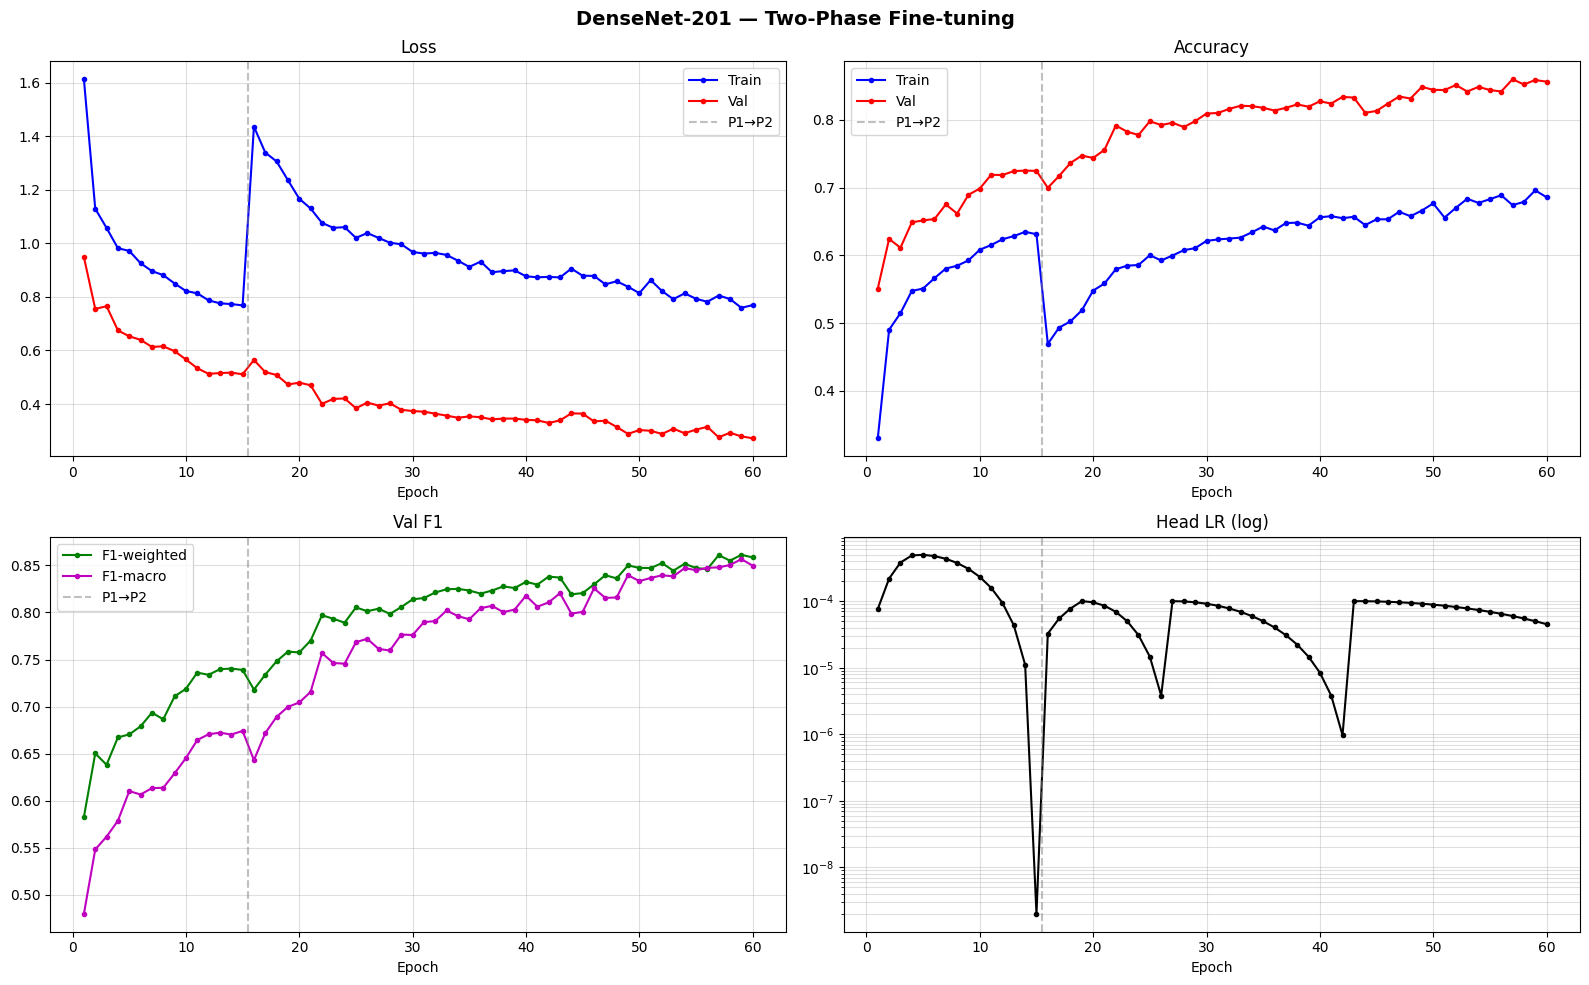

In [14]:
total_ep = len(history['train_loss'])
ep_range = range(1, total_ep + 1)
p1_end   = CFG['phase1_epochs']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes      = axes.ravel()

def divider(ax):
    ax.axvline(x=p1_end + 0.5, color='gray', ls='--', alpha=0.5, label='P1→P2')

axes[0].plot(ep_range, history['train_loss'], 'b-o', ms=3, label='Train')
axes[0].plot(ep_range, history['val_loss'],   'r-o', ms=3, label='Val')
divider(axes[0]); axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(ep_range, history['train_acc'], 'b-o', ms=3, label='Train')
axes[1].plot(ep_range, history['val_acc'],   'r-o', ms=3, label='Val')
divider(axes[1]); axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.4)

axes[2].plot(ep_range, history['val_f1_w'], 'g-o', ms=3, label='F1-weighted')
axes[2].plot(ep_range, history['val_f1_m'], 'm-o', ms=3, label='F1-macro')
divider(axes[2]); axes[2].set_title('Val F1'); axes[2].legend(); axes[2].grid(alpha=0.4)

axes[3].semilogy(ep_range, history['lr'], 'k-o', ms=3)
divider(axes[3]); axes[3].set_title('Head LR (log)'); axes[3].grid(alpha=0.4, which='both')

for ax in axes: ax.set_xlabel('Epoch')
plt.suptitle('DenseNet-201 — Two-Phase Fine-tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=120)
plt.show()


## Cell 15 — Load Best Model & Evaluate (Val + Test + TTA)

In [15]:
checkpoint = torch.load(CFG['p2_save_path'], map_location=CFG['device'], weights_only=False)
model.load_state_dict(checkpoint['model_state'])
print(f"Best: epoch={checkpoint['epoch']}  phase={checkpoint['phase']}  F1={checkpoint['best_f1']:.4f}")

# Validation
_, va_acc, va_f1_w, va_f1_m, va_preds, va_labels, va_probs = evaluate(
    model, val_loader, criterion, CFG['device'])
va_auc = roc_auc_score(va_labels, safe_normalize(va_probs),
                        multi_class='ovr', average='weighted')
print(f"\nVAL   Acc={va_acc:.4f}  F1-W={va_f1_w:.4f}  F1-M={va_f1_m:.4f}  AUC={va_auc:.4f}")
print(classification_report(va_labels, va_preds, target_names=class_names))

# Test standard
_, te_acc, te_f1_w, te_f1_m, te_preds, te_labels, te_probs = evaluate(
    model, test_loader, criterion, CFG['device'])
te_auc = roc_auc_score(te_labels, safe_normalize(te_probs),
                        multi_class='ovr', average='weighted')
print(f"TEST  Acc={te_acc:.4f}  F1-W={te_f1_w:.4f}  F1-M={te_f1_m:.4f}  AUC={te_auc:.4f}")
print(classification_report(te_labels, te_preds, target_names=class_names))

# TTA
print(f"\nRunning TTA ({len(tta_transforms)} views) …")
_, tta_acc, tta_f1_w, tta_f1_m, tta_preds, tta_labels, tta_probs = evaluate_tta(
    model, CACHE_DIR, 'test', criterion, CFG['device'], tta_transforms)
tta_auc = roc_auc_score(tta_labels, safe_normalize(tta_probs),
                         multi_class='ovr', average='weighted')
print(f"TTA   Acc={tta_acc:.4f}  F1-W={tta_f1_w:.4f}  F1-M={tta_f1_m:.4f}  AUC={tta_auc:.4f}")
print(classification_report(tta_labels, tta_preds, target_names=class_names))


Best: epoch=44  phase=phase2  F1=0.8613

VAL   Acc=0.8587  F1-W=0.8613  F1-M=0.8566  AUC=0.9792
                               precision    recall  f1-score   support

            Actinic keratoses       0.57      0.76      0.65        86
         Basal cell carcinoma       0.78      0.86      0.82       332
Benign keratosis-like lesions       0.68      0.74      0.71       262
                   Chickenpox       0.96      0.99      0.97       112
                       Cowpox       0.99      1.00      0.99        99
               Dermatofibroma       0.66      0.91      0.76        23
                         HFMD       1.00      1.00      1.00       241
                      Healthy       1.00      1.00      1.00       171
                      Measles       0.99      1.00      0.99        82
             Melanocytic nevi       0.92      0.83      0.87      1287
                     Melanoma       0.68      0.71      0.69       452
                    Monkeypox       1.00      0.99 

## Cell 16 — Confusion Matrix (Test + TTA)

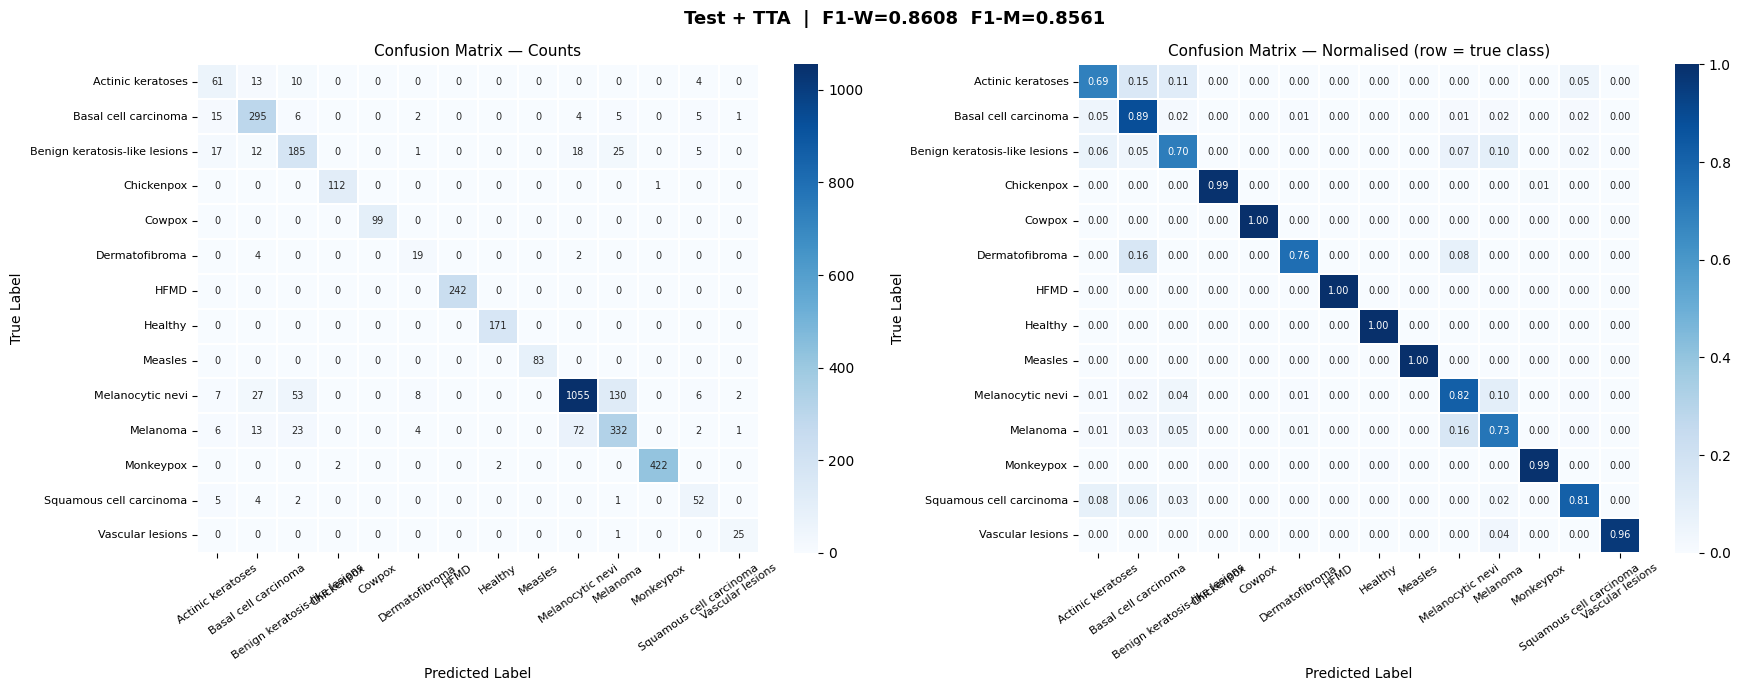

In [16]:
cm      = confusion_matrix(tta_labels, tta_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title in zip(
        axes, [cm, cm_norm], ['d', '.2f'],
        ['Counts', 'Normalised (row = true class)']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.3, annot_kws={'size': 7})
    ax.set_title(f'Confusion Matrix — {title}', fontsize=11)
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle(f'Test + TTA  |  F1-W={tta_f1_w:.4f}  F1-M={tta_f1_m:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=120)
plt.show()


## Cell 17 — Per-Class F1 Chart

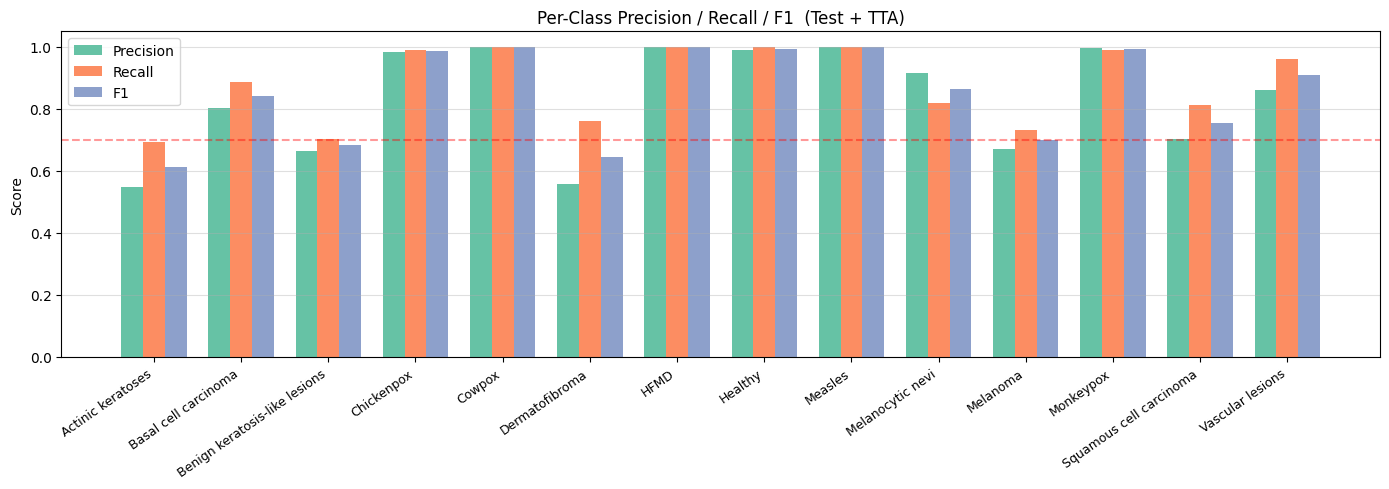


Class                                  Prec     Rec      F1     Sup
--------------------------------------------------------------
Actinic keratoses                     0.550   0.693   0.613      88
Dermatofibroma                        0.559   0.760   0.644      25
Benign keratosis-like lesions         0.663   0.703   0.683     263
Melanoma                              0.672   0.733   0.701     453
Squamous cell carcinoma               0.703   0.812   0.754      64
Basal cell carcinoma                  0.802   0.886   0.842     333
Melanocytic nevi                      0.917   0.819   0.865    1288
Vascular lesions                      0.862   0.962   0.909      26
Chickenpox                            0.982   0.991   0.987     113
Monkeypox                             0.998   0.991   0.994     426
Healthy                               0.988   1.000   0.994     171
Cowpox                                1.000   1.000   1.000      99
HFMD                                  1.000   1.000 

In [17]:
report   = classification_report(tta_labels, tta_preds,
              target_names=class_names, output_dict=True, zero_division=0)
per_f1   = [report[c]['f1-score']  for c in class_names]
per_prec = [report[c]['precision'] for c in class_names]
per_rec  = [report[c]['recall']    for c in class_names]

x, w    = np.arange(num_classes), 0.25
palette = sns.color_palette('Set2', 3)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w, per_prec, w, label='Precision', color=palette[0])
ax.bar(x,     per_rec,  w, label='Recall',    color=palette[1])
ax.bar(x + w, per_f1,   w, label='F1',        color=palette[2])
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1  (Test + TTA)')
ax.axhline(0.7, color='red', ls='--', alpha=0.4); ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/per_class_f1.png', dpi=120)
plt.show()

print(f"\n{'Class':<35s}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'Sup':>6}")
print("-" * 62)
for cls, pr, re, f1, sup in sorted(
        zip(class_names, per_prec, per_rec, per_f1,
            [report[c]['support'] for c in class_names]),
        key=lambda x: x[3]):
    flag = " ⚠️" if f1 < 0.5 else ""
    print(f"{cls:<35s}  {pr:>6.3f}  {re:>6.3f}  {f1:>6.3f}  {int(sup):>6}{flag}")


## Cell 18 — ROC Curves (Test + TTA)

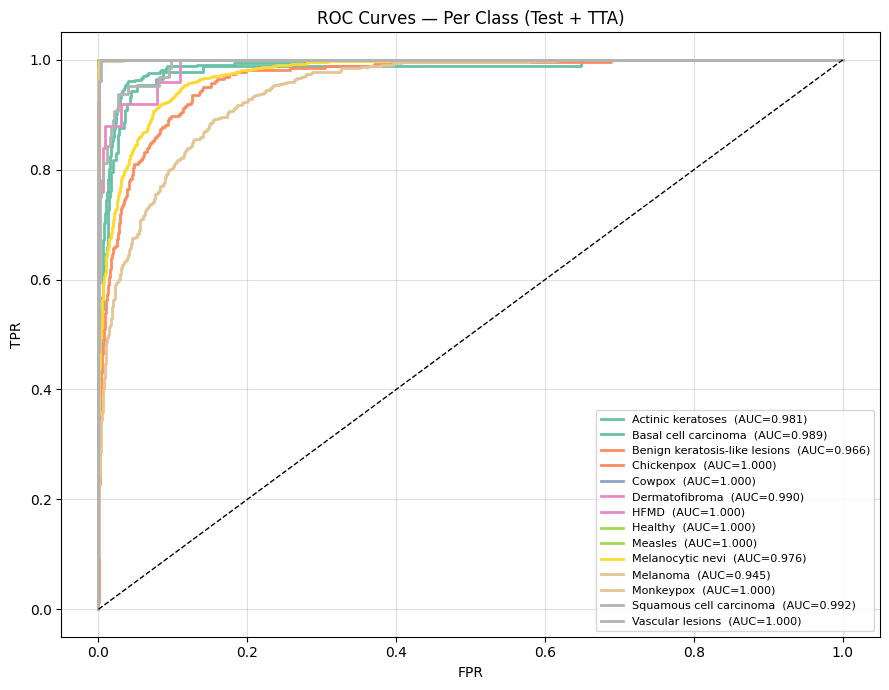

In [18]:
y_bin  = label_binarize(tta_labels, classes=list(range(num_classes)))
colors = plt.cm.Set2(np.linspace(0, 1, num_classes))

fig, ax = plt.subplots(figsize=(9, 7))
for i, (cls, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], tta_probs[:, i])
    auc_i       = roc_auc_score(y_bin[:, i], tta_probs[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls}  (AUC={auc_i:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — Per Class (Test + TTA)')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_curves.png', dpi=120)
plt.show()


## Cell 19 — Grad-CAM++ Interpretability



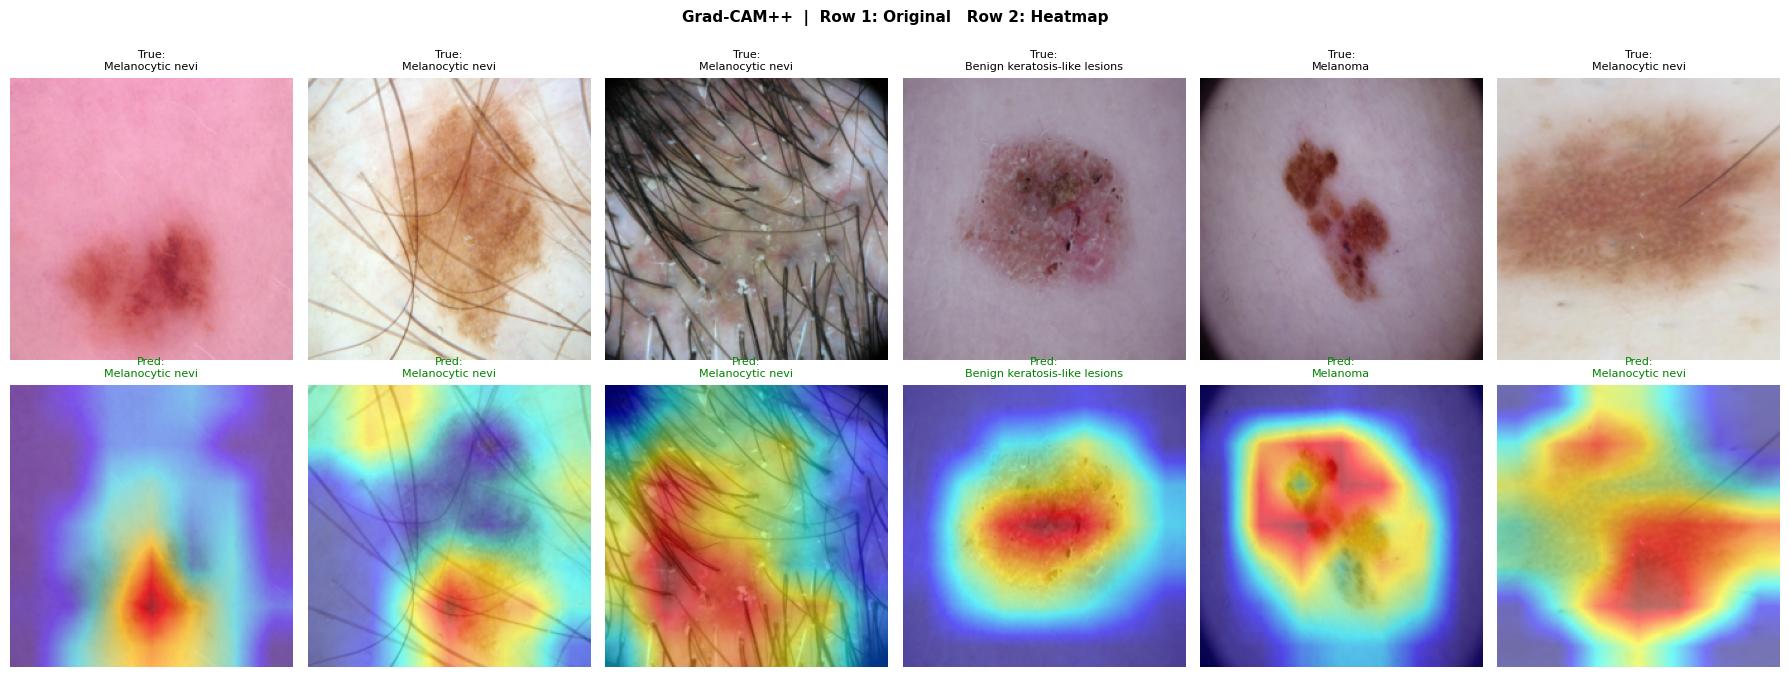

In [19]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

model.eval()

# DenseNet-201 Grad-CAM target: last dense block before global pooling
target_layers  = [model.backbone.features.denseblock4]
cam            = GradCAMPlusPlus(model=model, target_layers=target_layers)

n_samples      = 6
sample_indices = random.sample(range(len(val_dataset)), n_samples)
fig, axes      = plt.subplots(2, n_samples, figsize=(3 * n_samples, 7))

for col, idx in enumerate(sample_indices):
    tensor_img, true_label = val_dataset[idx]
    input_tensor           = tensor_img.unsqueeze(0).to(CFG['device'])
    rgb  = np.clip(tensor_img.permute(1,2,0).numpy() * STD + MEAN, 0, 1).astype(np.float32)

    grayscale_cam = cam(input_tensor=input_tensor,
                        targets=[ClassifierOutputTarget(true_label.item())])[0]
    cam_image = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

    with torch.no_grad():
        pred = model(input_tensor).argmax(1).item()

    axes[0, col].imshow(rgb); axes[0, col].axis('off')
    axes[0, col].set_title(f"True:\n{class_names[true_label]}", fontsize=8)
    color = 'green' if pred == true_label else 'red'
    axes[1, col].imshow(cam_image); axes[1, col].axis('off')
    axes[1, col].set_title(f"Pred:\n{class_names[pred]}", fontsize=8, color=color)

plt.suptitle("Grad-CAM++  |  Row 1: Original   Row 2: Heatmap\n"
             , fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/gradcam.png', dpi=120)
plt.show()


## Cell 20 — Single Image Prediction

True: HFMD


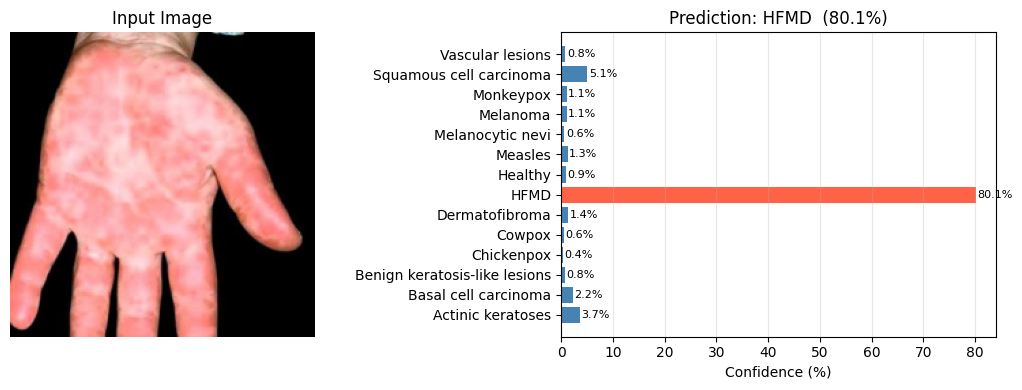

Pred: HFMD  (80.09%)


In [20]:
def predict_single_image(image_path_or_pil, model, class_names, device):
    model.eval()
    img_pil = (Image.open(image_path_or_pil).convert('RGB')
               if isinstance(image_path_or_pil, str)
               else image_path_or_pil.convert('RGB'))
    img_np  = np.array(img_pil.resize((CFG['img_size'], CFG['img_size'])))
    tensor  = val_transforms(image=img_np)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1).squeeze().cpu().numpy()
    pred_idx = int(probs.argmax())

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(img_pil.resize((224, 224))); axes[0].axis('off')
    axes[0].set_title('Input Image')
    bar_colors = ['tomato' if i == pred_idx else 'steelblue' for i in range(len(class_names))]
    axes[1].barh(class_names, probs * 100, color=bar_colors)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title(f"Prediction: {class_names[pred_idx]}  ({probs[pred_idx]*100:.1f}%)")
    for i, v in enumerate(probs * 100):
        axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)
    axes[1].grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()
    return class_names[pred_idx], round(float(probs[pred_idx]) * 100, 2)

idx              = random.randint(0, len(val_dataset) - 1)
tensor_img, true = val_dataset[idx]
rgb              = np.clip(tensor_img.permute(1,2,0).numpy() * STD + MEAN, 0, 1)
pil_img          = Image.fromarray((rgb * 255).astype(np.uint8))
print(f"True: {class_names[true]}")
pred_class, conf = predict_single_image(pil_img, model, class_names, CFG['device'])
print(f"Pred: {pred_class}  ({conf}%)")


## Cell 21 — Save & Final Summary

In [21]:
metadata = {
    'model'           : 'densenet201',
    'img_size'        : CFG['img_size'],
    'num_classes'     : num_classes,
    'class_names'     : class_names,
    'best_val_f1'     : round(float(checkpoint['best_f1']), 4),
    'test_f1_weighted': round(float(te_f1_w), 4),
    'test_f1_macro'   : round(float(te_f1_m), 4),
    'test_tta_f1_w'   : round(float(tta_f1_w), 4),
    'test_tta_f1_m'   : round(float(tta_f1_m), 4),
    'test_auc'        : round(float(tta_auc), 4),
    'test_acc'        : round(float(tta_acc), 4),
}
with open(f'{SAVE_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("\n" + "=" * 55)
print("  FINAL SUMMARY — DenseNet-201")
print("=" * 55)
print(f"  Model            : DenseNet-201  ({CFG['img_size']}×{CFG['img_size']})")
print(f"  Best Val F1-W    : {metadata['best_val_f1']:.4f}")
print(f"  Test F1-Weighted : {metadata['test_f1_weighted']:.4f}")
print(f"  Test F1-Macro    : {metadata['test_f1_macro']:.4f}")
print(f"  Test TTA F1-W    : {metadata['test_tta_f1_w']:.4f}  ← final metric")
print(f"  Test AUC         : {metadata['test_auc']:.4f}")
print(f"  Test Accuracy    : {metadata['test_acc']:.4f}")
print("=" * 55)
print("\nSaved to Drive:")
for f in sorted(os.listdir(SAVE_DIR)):
    sz = os.path.getsize(f'{SAVE_DIR}/{f}')
    print(f"  {f:<42s} {sz/1e6:6.2f} MB")



  FINAL SUMMARY — DenseNet-201
  Model            : DenseNet-201  (224×224)
  Best Val F1-W    : 0.8613
  Test F1-Weighted : 0.8588
  Test F1-Macro    : 0.8533
  Test TTA F1-W    : 0.8608  ← final metric
  Test AUC         : 0.9806
  Test Accuracy    : 0.8582

Saved to Drive:
  best_model_phase1.pth                       77.79 MB
  best_model_phase2.pth                       77.79 MB
  class_distribution.png                       0.12 MB
  confusion_matrix.png                         0.16 MB
  gradcam.png                                  1.75 MB
  metadata.json                                0.00 MB
  per_class_f1.png                             0.08 MB
  roc_curves.png                               0.10 MB
  sample_images.png                            7.76 MB
  training_curves.png                          0.19 MB
